# APPLES

### IMPORT

In [7]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### DATA

In [8]:
months = [
    # "201901", "201902", "201903", "201904", "201905", "201906",
    # "201907", "201908", "201909", "201910", "201911", "201912",
    # "202001", "202002", "202003", "202004", "202005", "202006",
    # "202007", "202008", "202009", "202010", "202011", "202012",
    # "202101", "202102", "202103", "202104", "202105", "202106",
    # "202107", "202108", "202109", "202110", "202111", "202112",
    # "202201", "202202", "202203", "202204", "202205", "202206",
    # "202207", "202208", "202209", "202210", "202211", "202212",
    # "202301", "202302", "202303", "202304", "202305", "202306",
    # "202307", "202308", "202309", "202310", "202311", "202312",
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 22196 rows
                                   Asset_A    Bid_A    Ask_A   Asset_B  \
timestamp                                                                
2024-01-02 10:12:52.660000+00:00  0.681490  0.68144  0.68154  0.630575   
2024-01-02 10:18:46.229000+00:00  0.681295  0.68123  0.68136  0.630540   
2024-01-02 10:25:10.405000+00:00  0.681155  0.68110  0.68121  0.630510   

                                    Bid_B    Ask_B     Log_A     Log_B  \
timestamp                                                                
2024-01-02 10:12:52.660000+00:00  0.63051  0.63064 -0.383474 -0.461123   
2024-01-02 10:18:46.229000+00:00  0.63050  0.63058 -0.383760 -0.461179   
2024-01-02 10:25:10.405000+00:00  0.63046  0.63056 -0.383965 -0.461226   

                                  Return_A  Return_B  HalfSpread_A_bps  \
timestamp                                                                
2024-01-02 10:12:52.660000+00:00 -0.000755 -0.000396          0.733686   
2024-01-02 10:18:46

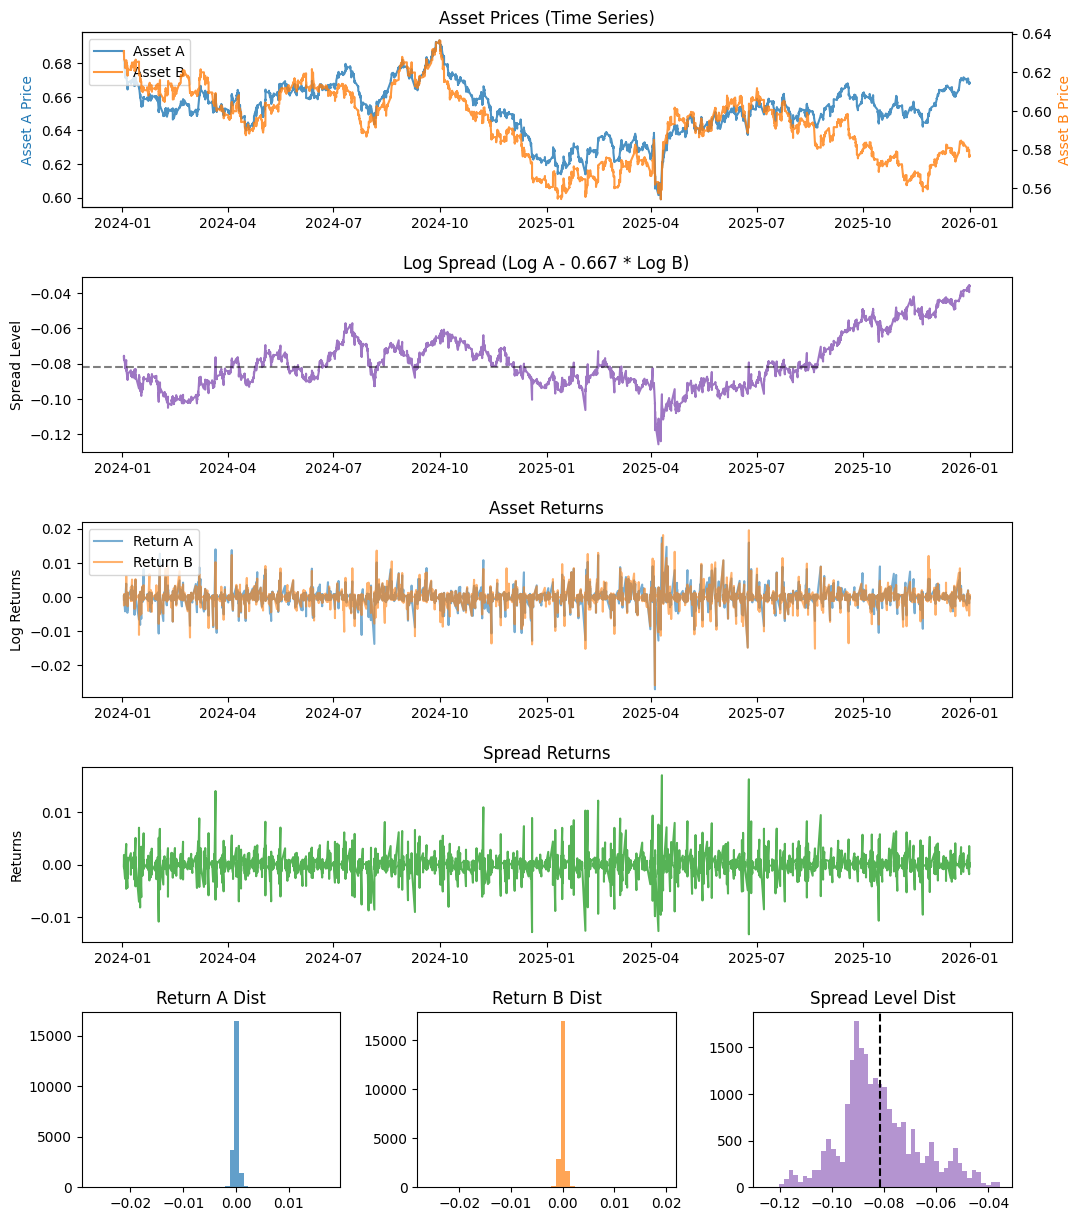

In [9]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(10, 14))
df = builder.build(my_files)

print(df.head(3))
print("\nColumns:", list(df.columns))
print(f"Median half-spread (bps) — A: {df['HalfSpread_A_bps'].median():.2f} | "
      f"B: {df['HalfSpread_B_bps'].median():.2f}")

# Call the new diagnostic plotter after the data is built
builder.plot_diagnostics()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.9143 | half-life=589.4 | β=0.6668

Rolling (2000-bar, step 200, n=101):
  p<0.05: 3.0% | p<0.10: 5.9%
  half-life: 60.8 (IQR 36–85)
  β: 0.7075 ±0.2800 [-0.3099, 1.3666]


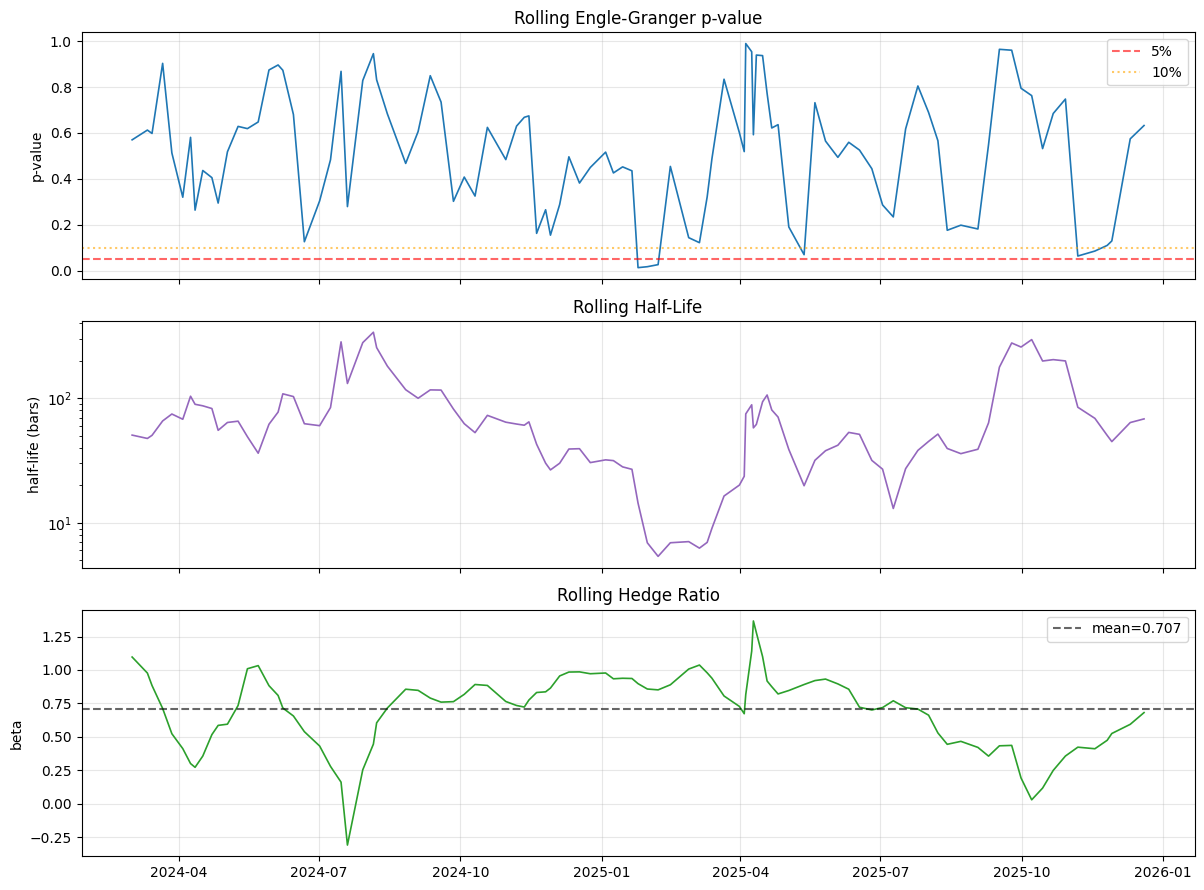

In [10]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)